### SVM

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_blobs

class SupportVectorMachine:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Convert labels to -1 and 1
        y_ = np.where(y <= 0, -1, 1)

        for _ in range(self.n_iterations):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.weights) - self.bias) >= 1
                if condition:
                    self.weights -= self.learning_rate * (2 * self.lambda_param * self.weights)
                else:
                    self.weights -= self.learning_rate * (2 * self.lambda_param * self.weights - np.dot(x_i, y_[idx]))
                    self.bias -= self.learning_rate * y_[idx]

    def predict(self, X):
        approx = np.dot(X, self.weights) - self.bias
        return np.sign(approx)

print("SupportVectorMachine class defined.")

SupportVectorMachine class defined.


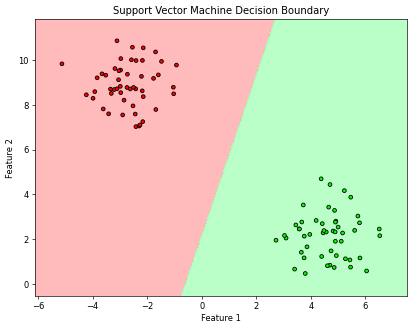

SVM Accuracy: 1.00


In [7]:
from sklearn.datasets import make_blobs

# Generate some synthetic data (reusing parameters from Perceptron example)
X_svm, y_svm = make_blobs(n_samples=100, n_features=2, centers=2, cluster_std=1.0, random_state=42)

# Create an SVM instance and fit the data
# Using slightly adjusted parameters for a potentially better fit, feel free to modify
svm_model = SupportVectorMachine(learning_rate=0.001, lambda_param=0.01, n_iterations=1000)
svm_model.fit(X_svm, y_svm)

# Reuse the plot_decision_boundary function defined previously
# Ensure it's available in the current execution context or redefine if needed
def plot_decision_boundary(X, y, model, title="Decision Boundary"):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Create color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFBB'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])

    plt.figure(figsize=(8, 6), dpi=60)
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

    # Plot the training points
    # Convert original y labels to -1 and 1 for consistent plotting with SVM's internal representation
    y_plot = np.where(y > 0, 1, -1) # Assuming original y was 0/1 or similar
    plt.scatter(X[:, 0], X[:, 1], c=y_plot, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(X_svm, y_svm, svm_model, title="Support Vector Machine Decision Boundary")

# Evaluate accuracy
y_pred_svm = svm_model.predict(X_svm)
# Convert original y labels to -1 and 1 for comparison with predictions
y_true_svm = np.where(y_svm > 0, 1, -1)
accuracy_svm = np.sum(y_pred_svm == y_true_svm) / len(y_svm)
print(f"SVM Accuracy: {accuracy_svm:.2f}")